**Nom :** [Double-cliquez ici pour entrer votre nom]

**Prénom :** [Double-cliquez ici pour entrer votre prénom]

# Mini-projet IA Chimie — Prédiction de toxicité avec Naive Bayes

## Objectif pédagogique

Dans ce notebook, nous allons découvrir une méthode d'intelligence artificielle **simple, probabiliste et interprétable** : le modèle **Naive Bayes**.

L'idée générale est la suivante :

> À partir de molécules déjà connues comme toxiques ou non toxiques, peut-on estimer la probabilité qu'une nouvelle molécule soit toxique ?

Ce notebook est conçu pour des étudiants de **L3 Chimie**. Il permet de montrer que l'IA ne se limite pas aux réseaux de neurones.

---

## Compétences travaillées

- Représenter une molécule par des propriétés numériques.
- Utiliser des descripteurs moléculaires simples avec RDKit.
- Comprendre une classification probabiliste.
- Évaluer un modèle avec une matrice de confusion et un score ROC-AUC.
- Interpréter les limites du modèle.

## 1. Principe de Naive Bayes

Naive Bayes repose sur le théorème de Bayes :

$$
P(\mathrm{Toxique} \mid \mathrm{propriétés}) =
\frac{P(\mathrm{propriétés} \mid \mathrm{Toxique}) P(\mathrm{Toxique})}
{P(\mathrm{propriétés})}
$$

En langage simple :

> On cherche la probabilité qu'une molécule soit toxique sachant ses propriétés chimiques.

Le mot **naive** signifie que le modèle suppose que les propriétés utilisées sont indépendantes les unes des autres.  
Cette hypothèse est souvent fausse en chimie, mais elle donne un modèle simple et très pédagogique.

In [64]:
# Installation éventuelle dans Google Colab
# Décommenter si nécessaire

# !pip install rdkit-pypi scikit-learn pandas matplotlib numpy

## 2. Importation des bibliothèques

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
ConfusionMatrixDisplay,
roc_auc_score,
RocCurveDisplay,
classification_report
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## 3. Création d'une petite base pédagogique de molécules

Pour éviter les problèmes d'installation ou de téléchargement, on commence avec une petite base simple.

Chaque molécule est décrite par son **SMILES** et une étiquette de toxicité.

> 💡 **Le saviez-vous ?** Le format **SMILES** (*Simplified Molecular Input Line Entry Specification*) est une notation qui permet de décrire la structure chimique d'une molécule sous la forme d'une simple ligne de texte (ex: l'Ethanol est noté `CCO`). C'est l'un des formats les plus utilisés en intelligence artificielle pour la chimie.

Nos étiquettes sont les suivantes :
- `0` : non toxique ou faible toxicité dans ce contexte pédagogique ;
- `1` : toxique ou substance préoccupante dans ce contexte pédagogique.

⚠️ Cette base est volontairement simplifiée. Elle ne remplace pas une vraie base toxicologique.

In [66]:
data = [
# Nom, SMILES, toxicité pédagogique
("Ethanol", "CCO", 0),
("Acetone", "CC(=O)C", 0),
("Acide acetique", "CC(=O)O", 0),
("Glycerol", "C(C(CO)O)O", 0),
("Glucose", "C(C1C(C(C(C(O1)O)O)O)O)O", 0),
("Cafeine", "Cn1cnc2n(C)c(=O)n(C)c(=O)c12", 0),
("Paracetamol", "CC(=O)NC1=CC=C(C=C1)O", 0),
("Aspirine", "CC(=O)OC1=CC=CC=C1C(=O)O", 0),
("Vanilline", "COC1=C(C=CC(=C1)C=O)O", 0),
("Acide citrique", "C(C(=O)O)C(CC(=O)O)(C(=O)O)O", 0),

("Benzene", "c1ccccc1", 1),
("Toluene", "Cc1ccccc1", 1),
("Phenol", "c1ccc(cc1)O", 1),
("Aniline", "c1ccc(cc1)N", 1),
("Chloroforme", "C(Cl)(Cl)Cl", 1),
("Tetrachloromethane", "C(Cl)(Cl)(Cl)Cl", 1),
("Chlorure de vinyle", "C=CCl", 1),
("Formaldehyde", "C=O", 1),
("Nitrobenzene", "C1=CC=C(C=C1)[N+](=O)[O-]", 1),
("Acrylonitrile", "C=CC#N", 1),
]

df = pd.DataFrame(data, columns=["Nom", "SMILES", "Toxique"])
df

,Nom,SMILES,Toxique
0,Ethanol,CCO,0
1,Acetone,CC(=O)C,0
2,Acide acetique,CC(=O)O,0
3,Glycerol,C(C(CO)O)O,0
4,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,0
5,Cafeine,Cn1cnc2n(C)c(=O)n(C)c(=O)c12,0
6,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,0
7,Aspirine,CC(=O)OC1=CC=CC=C1C(=O)O,0
8,Vanilline,COC1=C(C=CC(=C1)C=O)O,0
9,Acide citrique,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,0


## 4. Calcul de descripteurs moléculaires avec RDKit

In [67]:
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
    from rdkit.Chem.Draw import MolsToGridImage
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False
    print("RDKit n'est pas installé. Dans Google Colab, exécuter : !pip install rdkit-pypi")

RDKIT_AVAILABLE

True

In [68]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        "MolWt": Descriptors.MolWt(mol),                         # masse molaire
        "LogP": Crippen.MolLogP(mol),                            # lipophilie
        "TPSA": rdMolDescriptors.CalcTPSA(mol),                  # surface polaire
        "HBD": rdMolDescriptors.CalcNumHBD(mol),                 # donneurs H
        "HBA": rdMolDescriptors.CalcNumHBA(mol),                 # accepteurs H
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol), # liaisons rotatives
        "HeavyAtoms": mol.GetNumHeavyAtoms()                     # nombre d'atomes lourds
    }

if RDKIT_AVAILABLE:
    desc = df["SMILES"].apply(compute_descriptors)
    desc_df = pd.DataFrame(list(desc))
    df_desc = pd.concat([df, desc_df], axis=1)
    display(df_desc)
else:
    df_desc = df.copy()

,Nom,SMILES,Toxique,MolWt,LogP,TPSA,HBD,HBA,RotBonds,HeavyAtoms
0,Ethanol,CCO,0,46.069,-0.00140,20.23,1,1,0,3
1,Acetone,CC(=O)C,0,58.080,0.59530,17.07,0,1,0,4
2,Acide acetique,CC(=O)O,0,60.052,0.09090,37.30,1,1,0,4
3,Glycerol,C(C(CO)O)O,0,92.094,-1.66810,60.69,3,3,2,6
4,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,0,180.156,-3.22140,110.38,5,6,1,12
5,Cafeine,Cn1cnc2n(C)c(=O)n(C)c(=O)c12,0,194.194,-1.02930,61.82,0,3,0,14
6,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,0,151.165,1.35060,49.33,2,2,1,11
7,Aspirine,CC(=O)OC1=CC=CC=C1C(=O)O,0,180.159,1.31010,63.60,1,3,2,13
8,Vanilline,COC1=C(C=CC(=C1)C=O)O,0,152.149,1.21330,46.53,1,3,2,11
9,Acide citrique,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,0,192.123,-1.24850,132.13,4,4,5,13


## 5. Visualisation simple des molécules

Cette étape permet de relier les données numériques à la structure chimique.

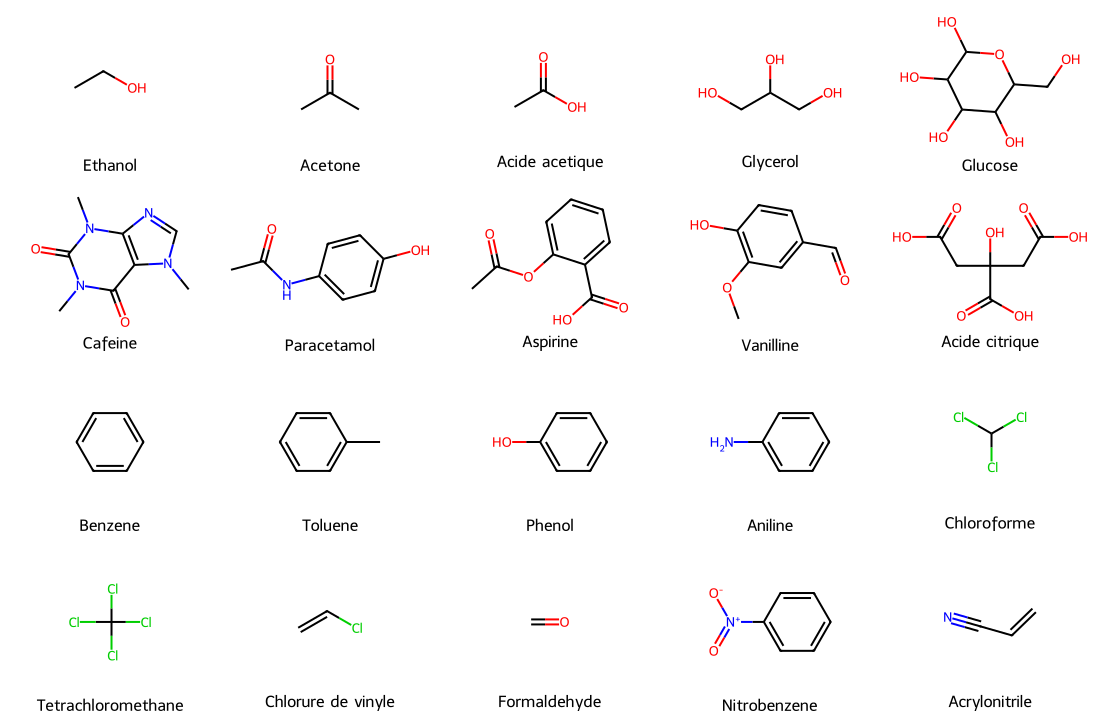

In [69]:
if RDKIT_AVAILABLE:
    mols = [Chem.MolFromSmiles(s) for s in df["SMILES"]]
    img = MolsToGridImage(mols, legends=df["Nom"].tolist(), molsPerRow=5, subImgSize=(220, 180))
    display(img)

## 6. Visualisation des données : LogP et masse molaire

On observe si les molécules toxiques et non toxiques se séparent facilement avec deux propriétés simples.

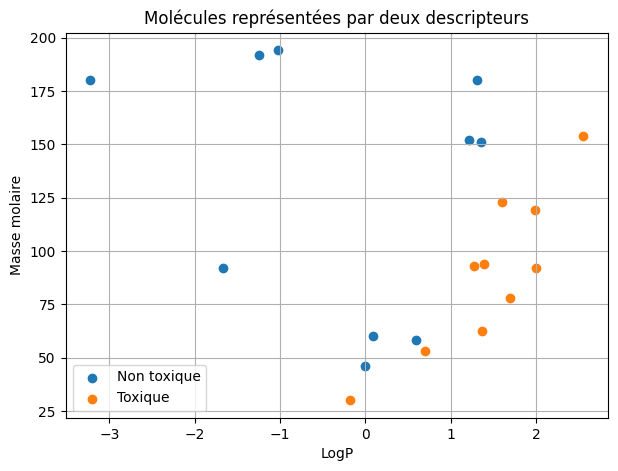

In [70]:
if RDKIT_AVAILABLE:
    plt.figure(figsize=(7, 5))
    for classe, label in [(0, "Non toxique"), (1, "Toxique")]:
        subset = df_desc[df_desc["Toxique"] == classe]
        plt.scatter(subset["LogP"], subset["MolWt"], label=label)
    plt.xlabel("LogP")
    plt.ylabel("Masse molaire")
    plt.title("Molécules représentées par deux descripteurs")
    plt.legend()
    plt.grid(True)
    plt.show()

## 7. Entraînement du modèle Naive Bayes

Nous utilisons ici `GaussianNB`, c'est-à-dire un Naive Bayes adapté à des variables numériques continues.

Le modèle apprend les distributions des propriétés chimiques dans chaque classe.

In [71]:
features = ["MolWt", "LogP", "TPSA", "HBD", "HBA", "RotBonds", "HeavyAtoms"]

X = df_desc[features]
y = df_desc["Toxique"]

# Attention : le jeu de données est petit.
# On garde stratify=y pour conserver les deux classes dans train/test.
X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, df_desc["Nom"],
    test_size=0.35,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

## 8. Résultats du modèle

In [72]:
results = pd.DataFrame({
    "Molécule": names_test.values,
    "Classe réelle": y_test.values,
    "Classe prédite": y_pred,
    "Probabilité toxique": y_proba
}).sort_values("Probabilité toxique", ascending=False)

display(results)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred, target_names=["Non toxique", "Toxique"]))

,Molécule,Classe réelle,Classe prédite,Probabilité toxique
4,Chloroforme,1,1,9.999802e-01
3,Aniline,1,1,9.897781e-01
1,Formaldehyde,1,0,4.425746e-01
0,Vanilline,0,0,2.587241e-10
2,Aspirine,0,0,1.755461e-13
5,Glycerol,0,0,9.120792e-30
6,Glucose,0,0,2.223396e-75


Accuracy : 0.8571428571428571
ROC-AUC : 1.0

              precision    recall  f1-score   support

 Non toxique       0.80      1.00      0.89         4
     Toxique       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



## 9. Matrice de confusion

La **matrice de confusion** permet de visualiser les performances du modèle en détaillant le type de ses erreurs :
- **Vrais Positifs (en bas à droite)** : Molécules toxiques correctement prédites comme toxiques.
- **Vrais Négatifs (en haut à gauche)** : Molécules non toxiques correctement prédites comme non toxiques.
- **Faux Positifs (en haut à droite)** : Molécules non toxiques considérées à tort comme toxiques (fausse alerte).
- **Faux Négatifs (en bas à gauche)** : Molécules toxiques considérées à tort comme non toxiques (danger !).

> *En toxicologie, un Faux Négatif est souvent l'erreur la plus critique, car on risquerait de libérer un produit dangereux.*

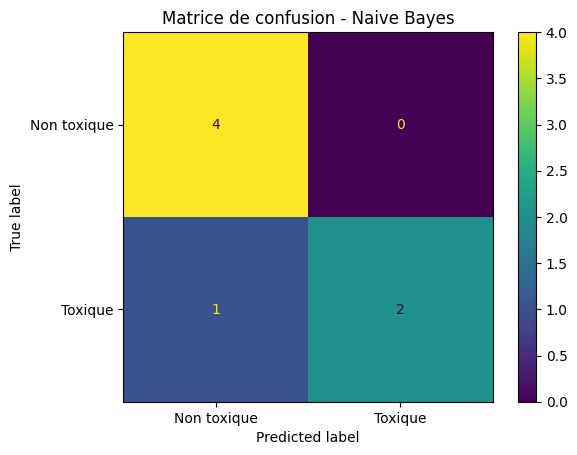

In [73]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non toxique", "Toxique"])
disp.plot()
plt.title("Matrice de confusion - Naive Bayes")
plt.show()

## 10. Courbe ROC et score AUC

La **courbe ROC** (*Receiver Operating Characteristic*) évalue la capacité du modèle à bien séparer les molécules toxiques des non toxiques.
Le score **AUC** (*Area Under the Curve*) correspond à l'aire sous cette courbe :
- **AUC = 0.5** : Le modèle répond complètement au hasard.
- **AUC = 1.0** : Le modèle sépare parfaitement les classes.

L'AUC est une métrique beaucoup plus fiable que la simple *Accuracy*, en particulier lorsque la base de données est déséquilibrée (par exemple s'il y a 90% de molécules saines pour seulement 10% de toxiques).

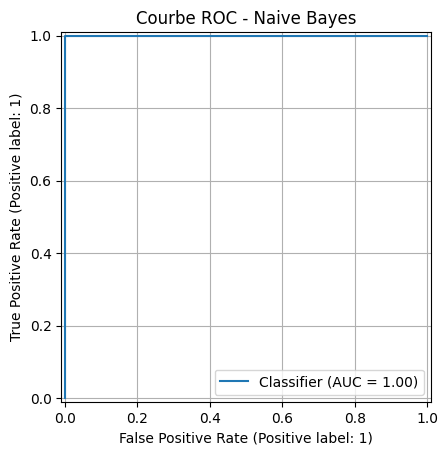

In [74]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Courbe ROC - Naive Bayes")
plt.grid(True)
plt.show()

## 11. Tester une molécule choisie par l'étudiant

Choisissez une molécule, trouvez son SMILES, puis testez-la avec le modèle.

Exemples :
- Ibuprofène : `CC(C)CC1=CC=C(C=C1)C(C)C(=O)O`
- Nicotine : `CN1CCC[C@H]1c2cccnc2`
- Menthol : `CC(C)C1CCC(C)CC1O`

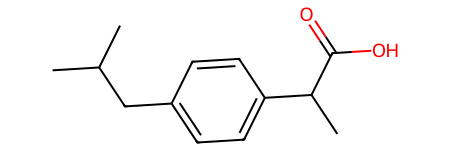

Molécule : Ibuprofene
SMILES : CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
Probabilité estimée de toxicité : 0.0
Classe prédite : Non toxique


,MolWt,LogP,TPSA,HBD,HBA,RotBonds,HeavyAtoms
0,206.285,3.0732,37.3,1,1,4,15


In [75]:
nom_molecule = "Ibuprofene"
smiles_molecule = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"

mol = Chem.MolFromSmiles(smiles_molecule)
display(mol)

desc_new = compute_descriptors(smiles_molecule)
x_new = pd.DataFrame([desc_new])[features]

proba_tox = model.predict_proba(x_new)[0, 1]
prediction = model.predict(x_new)[0]

print("Molécule :", nom_molecule)
print("SMILES :", smiles_molecule)
print("Probabilité estimée de toxicité :", round(proba_tox, 3))
print("Classe prédite :", "Toxique" if prediction == 1 else "Non toxique")
display(x_new)

## 12. Interprétation scientifique

Répondez aux questions suivantes directement dans les blocs prévus à cet effet.

### Questions générales sur les données

**1. Qu'est-ce que le format **SMILES** d'une molécule ? Donnez un exemple simple.**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

**2. Regardez la base de données (étape 3). L'Aspirine est-elle considérée comme toxique dans ce modèle pédagogique ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

**3. Pourquoi le **LogP** (coefficient de partage octanol/eau) est-il souvent utilisé pour estimer la capacité d'une molécule à traverser les membranes biologiques ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

### Questions sur le modèle d'Intelligence Artificielle

**4. Quelles propriétés moléculaires (descripteurs) sont utilisées par le modèle dans ce notebook ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

**5. L'hypothèse d'indépendance des variables (principe "Naive") est-elle réaliste en chimie ? Pourquoi ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

**6. Que signifie une probabilité de toxicité prédite de 0,70 ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

**7. Peut-on affirmer qu'une molécule est dangereuse ou sûre **uniquement** à partir de ce modèle ? Justifiez.**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

**8. Pourquoi le score ROC-AUC est-il plus informatif que la simple précision (accuracy) lorsqu'une base de données est déséquilibrée (ex: très peu de molécules toxiques parmi beaucoup de molécules saines) ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 13. Limites du modèle

Ce notebook est pédagogique. Il montre le principe de Naive Bayes, mais le modèle a plusieurs limites :

- la base de données est très petite ;
- les étiquettes de toxicité sont simplifiées ;
- les propriétés chimiques ne sont pas indépendantes ;
- la toxicité dépend aussi de la dose, de la voie d'exposition et du métabolisme ;
- le modèle ne remplace jamais une expertise toxicologique ou expérimentale.

Conclusion importante :

> En chimie, l'IA fournit une aide à la décision, mais elle ne remplace pas l'expérience, la validation expérimentale et l'esprit critique du chimiste.

## 14. Utilisation de données réelles : ClinTox avec DeepChem


Dans Google Colab, l'installation peut prendre un peu de temps :

```python
!pip install deepchem
```

Puis utiliser :

```python
import deepchem as dc
tasks, datasets, transformers = dc.molnet.load_clintox(featurizer="Raw", splitter="random")
```



In [76]:
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_clintox(
    featurizer="Raw",
    splitter="random"
)

train_dataset, valid_dataset, test_dataset = datasets

print("Tâches :", tasks)
print("Nombre de molécules train :", len(train_dataset))
print("Nombre de molécules test :", len(test_dataset))

Tâches : ['FDA_APPROVED', 'CT_TOX']
Nombre de molécules train : 1184
Nombre de molécules test : 148


### Préparation des données ClinTox

On extrait les SMILES et l'étiquette de toxicité (`CT_TOX`, qui correspond à la deuxième colonne des labels). On recalcule ensuite nos mêmes descripteurs RDKit.

In [77]:
# Fonction pour nettoyer et extraire les données
def extract_and_compute(dataset):
    data_list = []
    for i, smiles in enumerate(dataset.ids):
        desc = compute_descriptors(smiles)
        if desc is not None:  # RDKit a réussi à lire la molécule
            row = desc.copy()
            row["SMILES"] = smiles
            row["Toxique"] = dataset.y[i, 1]  # CT_TOX
            data_list.append(row)
    return pd.DataFrame(data_list)

print("Extraction des caractéristiques pour Train...")
df_train_dc = extract_and_compute(train_dataset)
print("Extraction des caractéristiques pour Test...")
df_test_dc = extract_and_compute(test_dataset)

print(f"Données nettoyées : Train = {len(df_train_dc)}, Test = {len(df_test_dc)}")

Extraction des caractéristiques pour Train...
Extraction des caractéristiques pour Test...
Données nettoyées : Train = 1184, Test = 148


### Entraînement et Évaluation sur ClinTox

On réutilise le même pipeline (StandardScaler + GaussianNB).

Résultats sur la base ClinTox (réelle) :

Accuracy : 0.959
ROC-AUC  : 0.742

Rapport de classification :
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98       142
         1.0       0.00      0.00      0.00         6

    accuracy                           0.96       148
   macro avg       0.48      0.50      0.49       148
weighted avg       0.92      0.96      0.94       148



c:\Doc_local\introduction_IA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Doc_local\introduction_IA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Doc_local\introduction_IA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


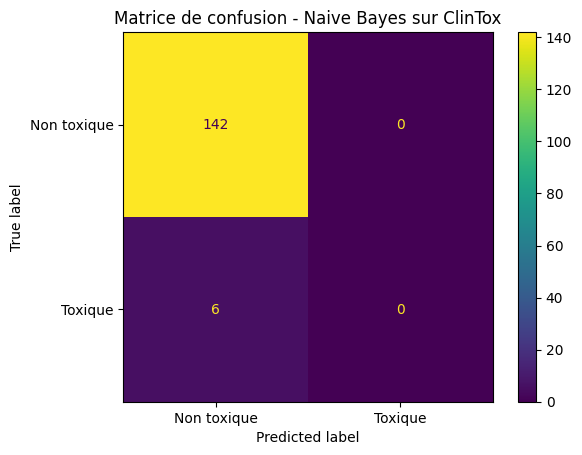

In [78]:
X_train_dc = df_train_dc[features]
y_train_dc = df_train_dc["Toxique"]

X_test_dc = df_test_dc[features]
y_test_dc = df_test_dc["Toxique"]

model_dc = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

model_dc.fit(X_train_dc, y_train_dc)
y_pred_dc = model_dc.predict(X_test_dc)
y_proba_dc = model_dc.predict_proba(X_test_dc)[:, 1]

print("Résultats sur la base ClinTox (réelle) :\n")
print("Accuracy :", round(accuracy_score(y_test_dc, y_pred_dc), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_dc, y_proba_dc), 3))
print("\nRapport de classification :\n", classification_report(y_test_dc, y_pred_dc))

# Matrice de confusion
cm_dc = confusion_matrix(y_test_dc, y_pred_dc)
disp_dc = ConfusionMatrixDisplay(cm_dc, display_labels=["Non toxique", "Toxique"])
disp_dc.plot()
plt.title("Matrice de confusion - Naive Bayes sur ClinTox")
plt.show()

### Analyse des résultats sur la vraie base ClinTox

**9. Comparez l'accuracy et le score ROC-AUC obtenus sur cette vraie base (ClinTox) par rapport à la petite base pédagogique du début du TP. Les performances de l'IA vous semblent-elles impactées par la complexité de données réelles ? Expliquez brièvement.**

**Réponse à la question 9 :**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

# Rendu du travail

Puisque vous avez répondu directement dans les cellules de ce document, **vous n'avez pas de fiche séparée à rendre**.

Assurez-vous simplement :
1. D'avoir bien indiqué vos noms et prénoms au tout début du notebook.
2. D'avoir répondu à toutes les questions dans les cellules bleues.
3. D'enregistrer ce fichier `.ipynb`.

Déposez ensuite directement ce notebook complété sur la plateforme de votre cours.